In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import copy

# 1. Load and split data
X, y = make_circles(n_samples=2000, noise=0.33, factor=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# Dictionary to store final weights for each configuration
saved_weights = {}

# Dictionary to store history for plotting
histories = {}

# Configurations to loop through
configs = ['None', 'L1', 'L2']


print(f"\n--- Training Model ---")

torch.manual_seed(42)

# 2. Re-initialize the model for each run to reset weights
model = nn.Sequential(
    nn.Linear(2, 500),
    nn.ReLU(),
    nn.Linear(500, 500),
    nn.ReLU(),
    nn.Linear(500, 2)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

epoch_ticks = []
train_accuracies = []
test_accuracies = []

best_weights = None
best_acc = 0.0

patience = 5
no_improvement = 0

epochs = 2000
for epoch in range(epochs):
    if no_improvement >= patience:
        break
    
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()

    # Track metrics every 25 epochs
    if (epoch + 1) % 25 == 0:
        model.eval()
        with torch.no_grad():
            _, train_predicted = torch.max(outputs, 1)
            train_acc = (train_predicted == y_train).sum().item() / y_train.size(0)
            
            test_outputs = model(X_test)
            _, test_predicted = torch.max(test_outputs, 1)
            test_acc = (test_predicted == y_test).sum().item() / y_test.size(0)

        if test_acc > best_acc:
            best_acc = test_acc
            best_weights = best_weights = copy.deepcopy(model.state_dict())
            no_improvement = 0
        else:
            no_improvement+=1
        
        epoch_ticks.append(epoch + 1)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f} | Train Acc: {train_acc*100:.1f}% | Test Acc: {test_acc*100:.1f}%")

print(f"Best test accuracy: {best_acc}")


--- Training Model ---
Epoch [25/2000] | Loss: 0.6437 | Train Acc: 67.2% | Test Acc: 67.9%
Epoch [50/2000] | Loss: 0.6174 | Train Acc: 73.2% | Test Acc: 73.4%
Epoch [75/2000] | Loss: 0.5944 | Train Acc: 74.8% | Test Acc: 76.0%
Epoch [100/2000] | Loss: 0.5741 | Train Acc: 76.7% | Test Acc: 76.4%
Epoch [125/2000] | Loss: 0.5560 | Train Acc: 76.9% | Test Acc: 77.4%
Epoch [150/2000] | Loss: 0.5402 | Train Acc: 77.2% | Test Acc: 77.6%
Epoch [175/2000] | Loss: 0.5265 | Train Acc: 77.4% | Test Acc: 77.2%
Epoch [200/2000] | Loss: 0.5149 | Train Acc: 77.6% | Test Acc: 77.1%
Epoch [225/2000] | Loss: 0.5051 | Train Acc: 77.8% | Test Acc: 77.2%
Epoch [250/2000] | Loss: 0.4970 | Train Acc: 77.5% | Test Acc: 77.2%
Epoch [275/2000] | Loss: 0.4903 | Train Acc: 77.8% | Test Acc: 77.1%
Best test accuracy: 0.77625


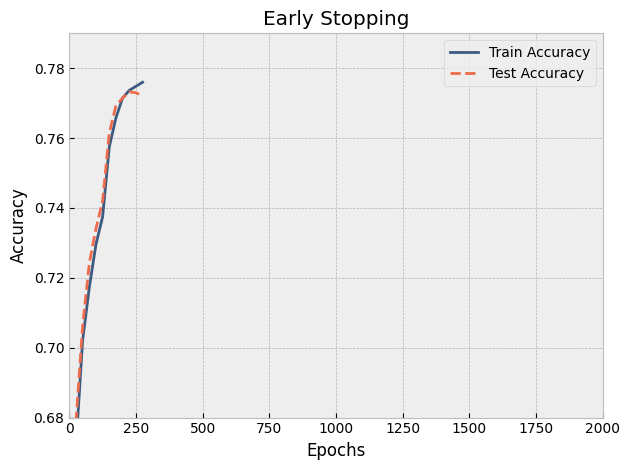

In [25]:
plt.style.use('bmh')
colors = ["#3d5a80", "#ee6c4d"]
window_size = 5

smooth_train = pd.Series(train_accuracies).rolling(window=window_size, min_periods=1).mean()
smooth_test = pd.Series(test_accuracies).rolling(window=window_size, min_periods=1).mean()

# Plot using the individual lists
plt.plot(epoch_ticks, smooth_train, label='Train Accuracy', color=colors[0], linewidth=2)
plt.plot(epoch_ticks, smooth_test, label='Test Accuracy', color=colors[1], linewidth=2, linestyle='--')

plt.title('Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Set axis limits
plt.xlim(0, 2000)
plt.ylim(0.68, 0.79)

plt.tight_layout()
plt.savefig('early_stopping.png')